In [21]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
scenario_folder_lake = select_scenario("lake", True)
scenario_folder_soil = select_scenario("soil", True)

Selected scenario: lake

Selected run: 2025-03-05_14:12
Selected scenario: soil

Selected run: 2025-03-05_09:45


In [23]:
node_pos_df_lake = load_node_pos_df(scenario_folder_lake)
monitor_sniffer_rx_df_lake  = load_monitor_sniffer_rx(scenario_folder_lake)
node_pos_df_soil = load_node_pos_df(scenario_folder_soil)
monitor_sniffer_rx_df_soil  = load_monitor_sniffer_rx(scenario_folder_soil)

In [24]:
# Append the most recent node positions (X, Y, Z) for SourceNodeId and DestinationNodeId at the time of the packet in each of the dataframes. Add a column for Distance
def append_node_pos(packet_df, node_pos_df):
    packet_df['SourceNodeId_X'] = packet_df['SourceNodeId'].map(node_pos_df.set_index('NodeId')['X'])
    packet_df['SourceNodeId_Y'] = packet_df['SourceNodeId'].map(node_pos_df.set_index('NodeId')['Y'])
    packet_df['SourceNodeId_Z'] = packet_df['SourceNodeId'].map(node_pos_df.set_index('NodeId')['Z'])
    packet_df['SourceNodeId_NodeType'] = packet_df['SourceNodeId'].map(node_pos_df.set_index('NodeId')['NodeType'])
    packet_df['DestinationNodeId_X'] = packet_df['DestinationNodeId'].map(node_pos_df.set_index('NodeId')['X'])
    packet_df['DestinationNodeId_Y'] = packet_df['DestinationNodeId'].map(node_pos_df.set_index('NodeId')['Y'])
    packet_df['DestinationNodeId_Z'] = packet_df['DestinationNodeId'].map(node_pos_df.set_index('NodeId')['Z'])
    packet_df['DestinationNodeId_NodeType'] = packet_df['DestinationNodeId'].map(node_pos_df.set_index('NodeId')['NodeType'])
    packet_df['Distance'] = np.sqrt((packet_df['SourceNodeId_X'] - packet_df['DestinationNodeId_X'])**2 + (packet_df['SourceNodeId_Y'] - packet_df['DestinationNodeId_Y'])**2 + (packet_df['SourceNodeId_Z'] - packet_df['DestinationNodeId_Z'])**2)
    
append_node_pos(monitor_sniffer_rx_df_lake, node_pos_df_lake)
append_node_pos(monitor_sniffer_rx_df_soil, node_pos_df_soil)

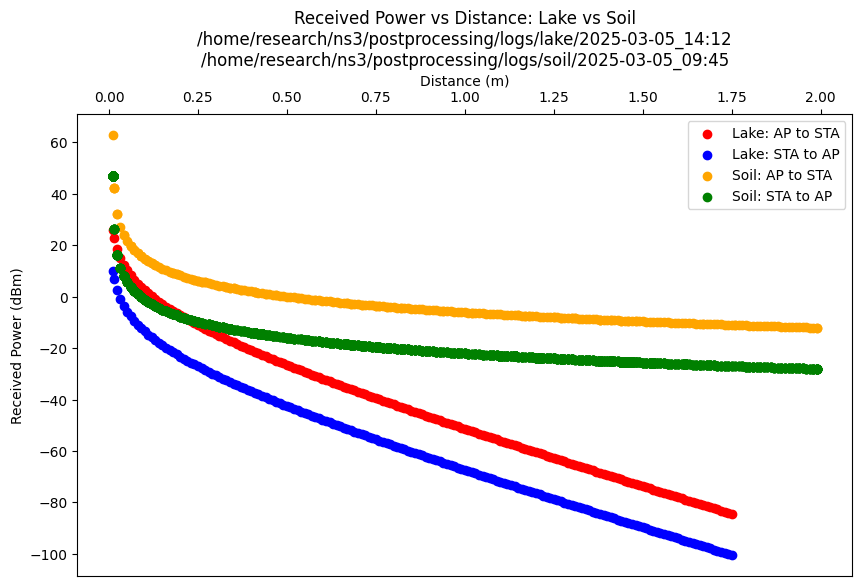

In [25]:
fig = plt.figure(figsize=(10, 6))

# Plot lake scenario
# AP to STA in red
ap_to_sta_lake = monitor_sniffer_rx_df_lake[
    (monitor_sniffer_rx_df_lake['SourceNodeId_NodeType'] == 'AP') & 
    (monitor_sniffer_rx_df_lake['DestinationNodeId_NodeType'] == 'STA')
]
plt.scatter(ap_to_sta_lake['Distance'], ap_to_sta_lake['SignalDbm'], c='red', label='Lake: AP to STA')

# STA to AP in blue
sta_to_ap_lake = monitor_sniffer_rx_df_lake[
    (monitor_sniffer_rx_df_lake['SourceNodeId_NodeType'] == 'STA') & 
    (monitor_sniffer_rx_df_lake['DestinationNodeId_NodeType'] == 'AP')
]
plt.scatter(sta_to_ap_lake['Distance'], sta_to_ap_lake['SignalDbm'], c='blue', label='Lake: STA to AP')

# Plot soil scenario
# AP to STA in orange
ap_to_sta_soil = monitor_sniffer_rx_df_soil[
    (monitor_sniffer_rx_df_soil['SourceNodeId_NodeType'] == 'AP') & 
    (monitor_sniffer_rx_df_soil['DestinationNodeId_NodeType'] == 'STA')
]
plt.scatter(ap_to_sta_soil['Distance'], ap_to_sta_soil['SignalDbm'], c='orange', label='Soil: AP to STA')

# STA to AP in green
sta_to_ap_soil = monitor_sniffer_rx_df_soil[
    (monitor_sniffer_rx_df_soil['SourceNodeId_NodeType'] == 'STA') & 
    (monitor_sniffer_rx_df_soil['DestinationNodeId_NodeType'] == 'AP')
]
plt.scatter(sta_to_ap_soil['Distance'], sta_to_ap_soil['SignalDbm'], c='green', label='Soil: STA to AP')

plt.xlabel('Distance (m)')
plt.ylabel('Received Power (dBm)')
plt.title(f'Received Power vs Distance: Lake vs Soil\n{scenario_folder_lake}\n{scenario_folder_soil}')
plt.legend()

# Move x-axis to top
ax = plt.gca()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.show()